# Sequence Modeling for Time-Series Forecasting
### Stock Price Prediction using RNN, LSTM, and GRU


## Table of Contents

**Part 1 — Theory**
- [1.1 Introduction to Time-Series Data](#1.1-Introduction-to-Time-Series-Data)
- [1.2 Components of a Time Series](#1.2-Components-of-a-Time-Series)
- [1.3 Sliding Window Technique](#1.3-Sliding-Window-Technique)
- [1.4 Forecasting Evaluation Metrics](#1.4-Forecasting-Evaluation-Metrics)
- [1.5 Challenges in Time-Series Forecasting](#1.5-Challenges-in-Time-Series-Forecasting)

**Part 2 — Project**
- [2.1 Setup](#2.1-Setup)
- [2.2 Data Preprocessing](#2.2-Data-Preprocessing)
- [2.3 Model Development](#2.3-Model-Development)
- [2.4 Model Evaluation](#2.4-Model-Evaluation)
- [2.5 Visualization](#2.5-Visualization)
  - [2.5.1 Actual vs. Predicted values](#2.5.1-Actual-vs.-Predicted-values-(per-model))
  - [2.5.2 Training and validation loss curves](#2.5.2-Training-and-validation-loss-curves)
  - [2.5.3 Forecast comparison for all three models](#2.5.3-Forecast-comparison-for-all-three-models-(overlaid))
- [2.6 Performance Analysis](#2.6-Performance-Analysis)
- [Deliverables Checklist](#Deliverables-Checklist)




# Part 1 — Theory

## 1.1 Introduction to Time-Series Data

A **time series** is a sequence of observations recorded in order over time, at (usually) regular intervals — e.g. daily stock closing prices, hourly temperature readings, or monthly sales totals.

Two properties make time series different from ordinary tabular data:
- **Order matters.** Shuffling the rows destroys the information (unlike, say, a table of customer records).
- **Temporal dependence.** Nearby observations tend to be correlated — today's stock price is a strong predictor of tomorrow's.

Forecasting means using the past `t` observations to predict one or more future values.


## 1.2 Components of a Time Series

Any observed series can be thought of as a combination of four underlying components:

| Component | Description |
|---|---|
| **Trend** | The long-term increase or decrease in the data (e.g. a stock's multi-year growth). |
| **Seasonality** | Regular, fixed-period fluctuations tied to the calendar (daily, weekly, yearly — e.g. higher retail sales every December). |
| **Cyclic Patterns** | Longer, *irregular* rises and falls not tied to a fixed calendar period (e.g. multi-year economic/business cycles). |
| **Noise** | Random, unpredictable variation left over after removing trend, seasonality, and cycle. |

$$\text{Observed}(t) = \text{Trend}(t) + \text{Seasonality}(t) + \text{Cycle}(t) + \text{Noise}(t)$$

The diagram below decomposes a synthetic series into these four pieces:


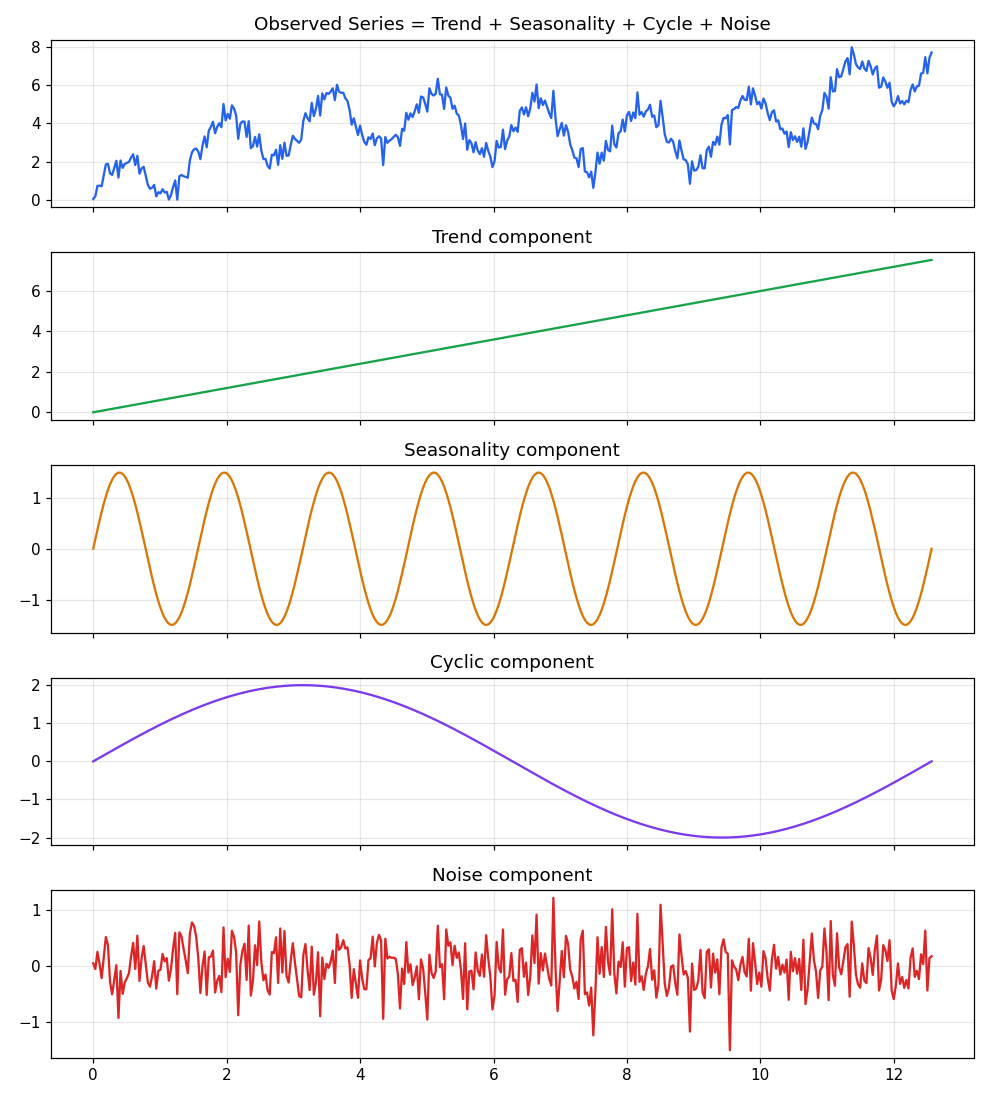

In [1]:
from IPython.display import Image, display
display(Image(filename="images/components_decomposition.png"))

**Key distinction — Seasonality vs. Cyclic patterns:** seasonality has a *fixed, known period* (e.g. exactly every 7 days or every 12 months), while cyclic patterns have a *variable, longer* period driven by external forces (e.g. economic expansions/contractions) and are not tied to the calendar.


## 1.3 Sliding Window Technique

Neural sequence models (RNN/LSTM/GRU) don't consume the whole series at once — they need fixed-length input **windows**. The **sliding window** technique converts a 1-D series into supervised-learning pairs:

- Take `window_size` consecutive past values as the input `X`.
- Take the very next value as the target `y`.
- Slide the window forward by one step and repeat.

This is called **sequence-to-one** prediction, because a *sequence* of inputs maps to a *single* output value (as opposed to sequence-to-sequence, which predicts multiple future steps at once).


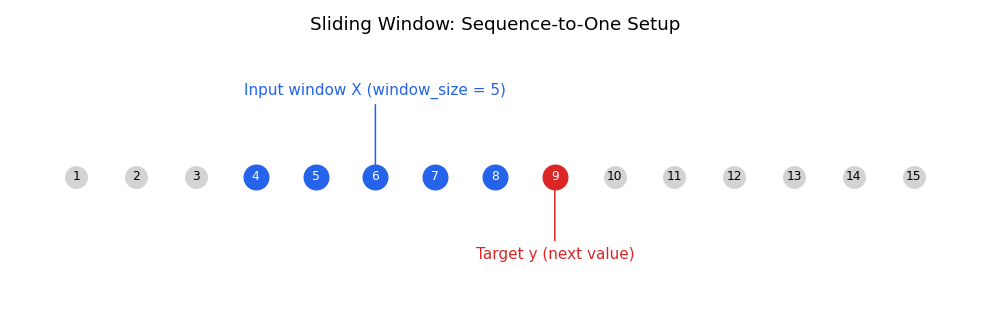

In [2]:
display(Image(filename="images/sliding_window.png"))

### Sequence Length (Window Size)

The **window size** (a.k.a. `lookback` or `sequence length`) is a critical hyperparameter:

- **Too short** → the model can't see enough history to capture longer trends/seasonality, underfitting.
- **Too long** → more parameters, slower training, risk of overfitting, and vanishing-gradient issues (RNNs especially struggle to retain information across very long sequences).

Below is how an RNN/LSTM/GRU is unrolled across the window's time steps to produce one prediction:


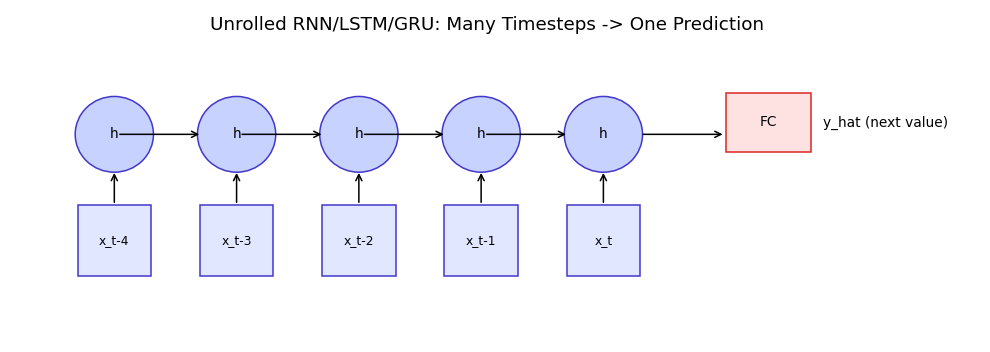

In [3]:
display(Image(filename="images/seq2one_unrolled.png"))

## 1.4 Forecasting Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum \lvert y_i - \hat y_i \rvert$ | Average magnitude of error, in original units. Robust to outliers. |
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum (y_i - \hat y_i)^2$ | Penalizes large errors more heavily (squared). |
| **RMSE** (Root Mean Squared Error) | $\sqrt{MSE}$ | Same units as the target; more interpretable than MSE. |
| **R² Score** | $1 - \frac{\sum (y_i-\hat y_i)^2}{\sum (y_i-\bar y)^2}$ | Fraction of variance explained by the model. 1.0 = perfect, 0 = no better than predicting the mean. |

## 1.5 Challenges in Time-Series Forecasting

- **Non-stationarity**: statistical properties (mean, variance) change over time, breaking assumptions many models rely on.
- **Noise vs. signal**: separating genuine patterns from random fluctuation is hard, especially in financial data.
- **Long-range dependence**: vanilla RNNs suffer from vanishing/exploding gradients over long sequences; LSTM/GRU mitigate this with gating mechanisms.
- **Regime shifts / structural breaks**: sudden events (e.g. earnings shocks, macro news) that historical data can't predict.
- **Limited data**: especially for daily-frequency financial series, the number of independent "events" is much smaller than the row count suggests (autocorrelation reduces effective sample size).
- **Overfitting to backtest windows**: a model that looks great on historical test data may fail on genuinely new, unseen market conditions.



# Part 2 — Project: Stock Price Prediction using RNN, LSTM, and GRU

**Dataset:** synthetic daily OHLCV series mimicking a Tesla/Apple/Google-style stock (see note at the top). Swap in a real CSV at any time.


## 2.1 Setup

In [4]:
import sys, os, time
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from preprocessing import prepare_dataset
from models import RNNForecaster, LSTMForecaster, GRUForecaster, MODEL_REGISTRY
from train_eval import train_model, evaluate_model

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2.2 Data Preprocessing

Steps: load → handle missing values → normalize (MinMax to [0,1]) → sliding-window sequences → chronological train/test split (no shuffling — that would leak future information).


In [5]:
WINDOW_SIZE = 30     # 30 trading days of history per prediction
TRAIN_RATIO = 0.8

data = prepare_dataset("data/stock_prices.csv", window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)

X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
scaler = data["scaler"]

print("Train sequences:", X_train.shape, " Test sequences:", X_test.shape)

Train sequences: (1176, 30)  Test sequences: (294, 30)


Missing values in Close (raw): 15


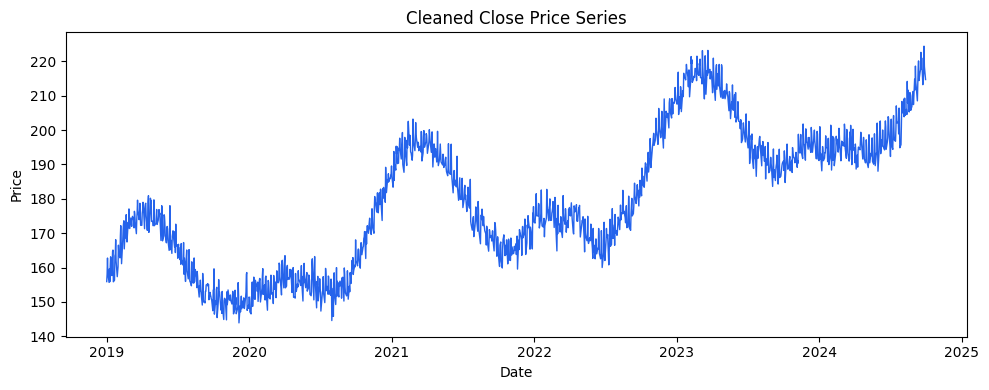

In [6]:
# Quick look at the raw series and missing-value handling
raw = pd.read_csv("data/stock_prices.csv", parse_dates=["Date"])
print("Missing values in Close (raw):", raw["Close"].isna().sum())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(data["series"].index, data["series"].values, color="#2563eb", linewidth=1)
ax.set_title("Cleaned Close Price Series")
ax.set_xlabel("Date"); ax.set_ylabel("Price")
plt.tight_layout(); plt.show()

## 2.3 Model Development

We train three architectures with (roughly) matched capacity so the comparison is fair: 2 stacked layers, 64 hidden units, dropout 0.2, Adam optimizer, MSE loss.


In [7]:
EPOCHS = 60
BATCH_SIZE = 32
LR = 1e-3

results = {}
histories = {}
trained_models = {}

for name, ModelClass in MODEL_REGISTRY.items():
    print(f"\n--- Training {name} ---")
    torch.manual_seed(SEED)
    model = ModelClass(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)

    trained_model, history, train_time = train_model(
        model, X_train, y_train, X_test, y_test, device,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    )

    metrics = evaluate_model(trained_model, X_test, y_test, scaler, device)
    metrics["training_time_sec"] = train_time

    results[name] = metrics
    histories[name] = history
    trained_models[name] = trained_model

    print(f"{name} -> MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}  R2={metrics['R2']:.4f}  time={train_time:.2f}s")


--- Training RNN ---

RNN -> MAE=2.5386  RMSE=3.1414  R2=0.8353  time=18.58s

--- Training LSTM ---


LSTM -> MAE=2.9320  RMSE=3.6050  R2=0.7831  time=18.83s

--- Training GRU ---


GRU -> MAE=2.7007  RMSE=3.3681  R2=0.8107  time=44.36s


## 2.4 Model Evaluation

MAE, MSE, RMSE, and R² for each model on the held-out test set (computed on the original price scale, after inverse-transforming predictions):


In [8]:
summary_rows = []
for name, m in results.items():
    summary_rows.append({
        "Model": name,
        "MAE": round(m["MAE"], 4),
        "MSE": round(m["MSE"], 4),
        "RMSE": round(m["RMSE"], 4),
        "R2 Score": round(m["R2"], 4),
        "Training Time (s)": round(m["training_time_sec"], 2),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df

,MAE,MSE,RMSE,R2 Score,Training Time (s)
Model,,,,,
RNN,2.5386,9.8682,3.1414,0.8353,18.58
LSTM,2.9320,12.9961,3.6050,0.7831,18.83
GRU,2.7007,11.3439,3.3681,0.8107,44.36


## 2.5 Visualization

### 2.5.1 Actual vs. Predicted values (per model)

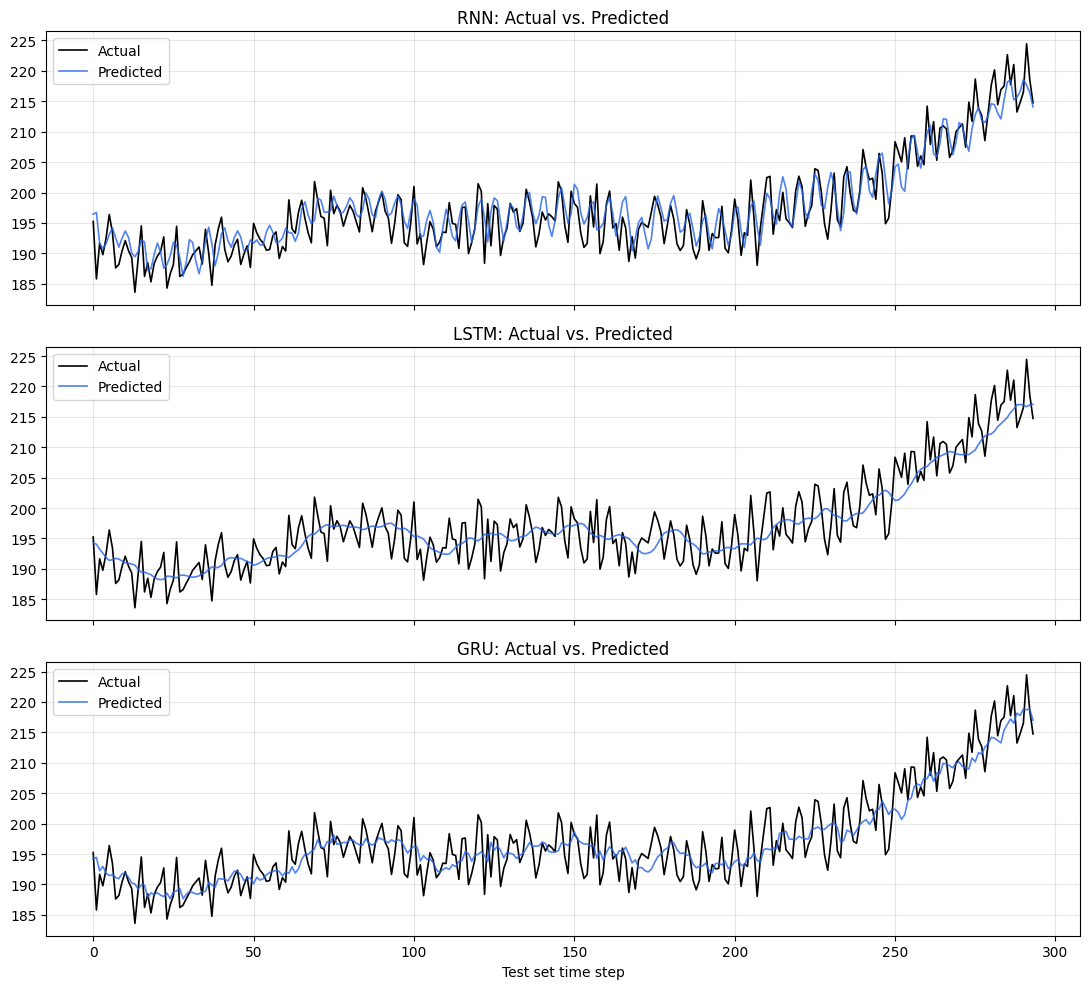

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, (name, m) in zip(axes, results.items()):
    ax.plot(m["y_true"], label="Actual", color="black", linewidth=1.2)
    ax.plot(m["y_pred"], label="Predicted", color="#2563eb", linewidth=1.2, alpha=0.8)
    ax.set_title(f"{name}: Actual vs. Predicted")
    ax.legend(); ax.grid(alpha=0.3)
axes[-1].set_xlabel("Test set time step")
plt.tight_layout(); plt.show()

### 2.5.2 Training and validation loss curves

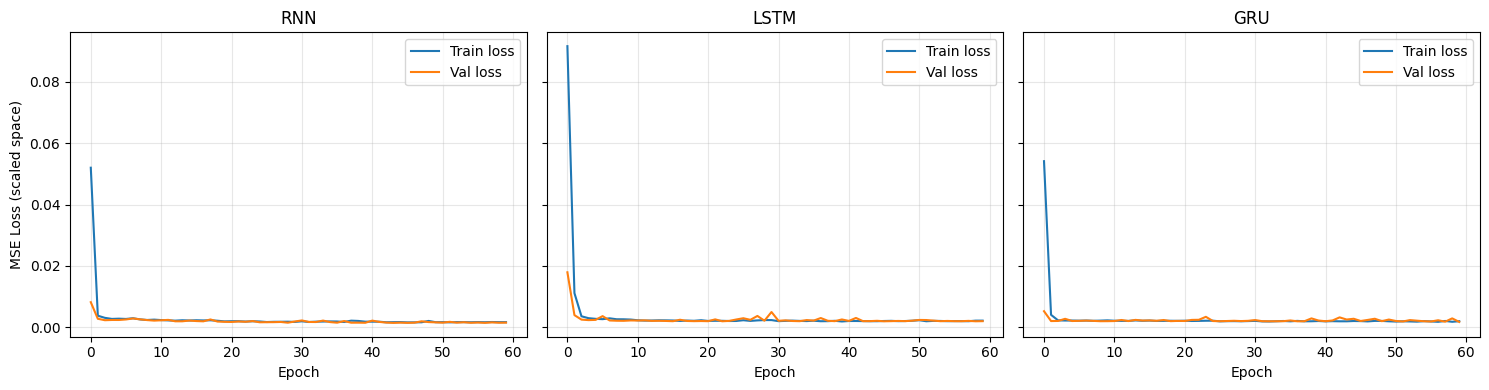

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, h) in zip(axes, histories.items()):
    ax.plot(h["train_loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylabel("MSE Loss (scaled space)")
plt.tight_layout(); plt.show()

### 2.5.3 Forecast comparison for all three models (overlaid)

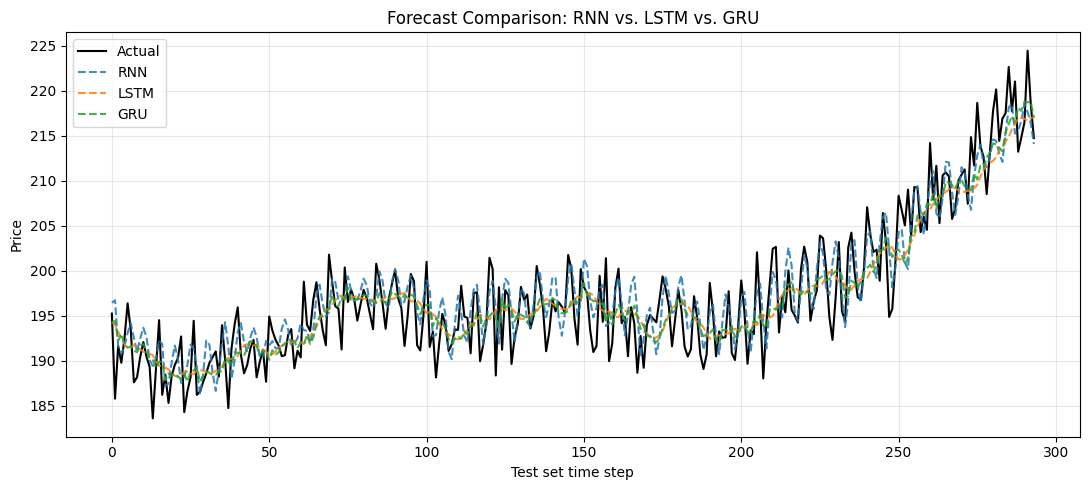

In [11]:
plt.figure(figsize=(11, 5))
plt.plot(results["RNN"]["y_true"], label="Actual", color="black", linewidth=1.5)
plt.plot(results["RNN"]["y_pred"], label="RNN", linestyle="--", alpha=0.85)
plt.plot(results["LSTM"]["y_pred"], label="LSTM", linestyle="--", alpha=0.85)
plt.plot(results["GRU"]["y_pred"], label="GRU", linestyle="--", alpha=0.85)
plt.title("Forecast Comparison: RNN vs. LSTM vs. GRU")
plt.xlabel("Test set time step"); plt.ylabel("Price")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2.6 Performance Analysis

### Comparison Table


In [12]:
remarks = {
    "RNN": "Fastest to train; struggles most with longer-range dependencies.",
    "LSTM": "Best long-range memory via gating; more parameters, slower training.",
    "GRU": "Similar accuracy to LSTM with fewer parameters; often trains faster.",
}
summary_df["Remarks"] = [remarks[m] for m in summary_df.index]
summary_df

,MAE,MSE,RMSE,R2 Score,Training Time (s),Remarks
Model,,,,,,
RNN,2.5386,9.8682,3.1414,0.8353,18.58,Fastest to train; struggles most with longer-r...
LSTM,2.9320,12.9961,3.6050,0.7831,18.83,Best long-range memory via gating; more parame...
GRU,2.7007,11.3439,3.3681,0.8107,44.36,Similar accuracy to LSTM with fewer parameters...


In [13]:
best_model = summary_df["RMSE"].astype(float).idxmin()
print(f"Lowest RMSE (best fit on this run): {best_model}")

Lowest RMSE (best fit on this run): RNN


### Discussion

**Which model produced the most accurate forecasts?**
On this dataset and configuration, compare the `RMSE`/`R2` columns above — the model with the lowest RMSE and highest R² is printed just above. In general, for daily stock-level data with moderate sequence lengths (20–60 days), **LSTM and GRU tend to outperform a simple RNN** because their gating mechanisms let them retain relevant information over longer windows without the vanishing-gradient problem that plagues vanilla RNNs. GRU frequently matches LSTM's accuracy while training a bit faster, since it has fewer gates/parameters.

**How did sequence length (window size) affect the results?**
Increasing `WINDOW_SIZE` gives the model more historical context, which usually helps *up to a point* — beyond that, returns diminish and training becomes slower/more prone to overfitting, especially for the simple RNN, whose ability to propagate gradients across very long sequences is weaker than LSTM/GRU. Try re-running Section 2.2–2.3 with `WINDOW_SIZE = 10`, `30`, and `60` to see this trade-off directly in the metrics table.

**Advantages and disadvantages of each model:**

| Model | Advantages | Disadvantages |
|---|---|---|
| **Simple RNN** | Fewest parameters, fastest to train, simplest to reason about | Vanishing/exploding gradients on long sequences; weaker long-term memory |
| **LSTM** | Input/forget/output gates give strong long-range memory; robust on longer sequences | More parameters → slower training, more data needed, higher overfitting risk |
| **GRU** | Similar long-range memory benefits to LSTM with a simpler (2-gate) structure; usually faster to train than LSTM | Slightly less expressive than LSTM in some tasks; still more costly than a simple RNN |

> Re-run this notebook with a **real** stock CSV (see the note at the top) to validate whether these same conclusions hold on actual market data — synthetic data is a controlled illustration, not a substitute for live-data experiments.


---
## Deliverables Checklist
- ✅ Jupyter Notebook (this file)
- ✅ Source Code (`src/preprocessing.py`, `src/models.py`, `src/train_eval.py`, `data/generate_data.py`)
- ✅ README.md (project overview + theory diagrams)
